# **6 Task-1**

In [ ]:

import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']
df = pd.read_csv(url, names=columns)
df.head()



,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:

print(f"\n2. Dataset Dimensions: {df.shape}")

print("\n3. Missing Values:")
print(df.isnull().sum())




2. Dataset Dimensions: (1372, 5)

3. Missing Values:
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [ ]:

print("\n4. Descriptive Statistics:")
df.describe()


4. Descriptive Statistics:


,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


# **6 Task-2**

<Figure size 800x600 with 0 Axes>

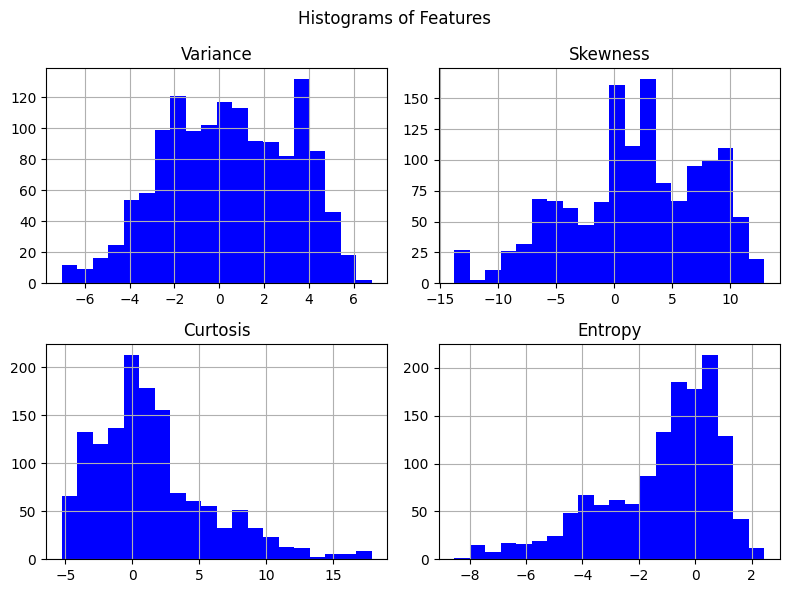

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
df.drop('Class', axis=1).hist(bins=20, color='blue',figsize=(8, 6))
plt.suptitle('Histograms of Features')
plt.tight_layout()
plt.savefig('task2_histograms.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

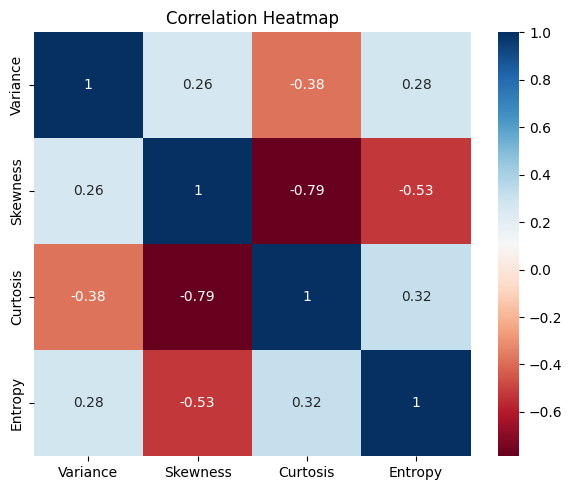

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[columns[:-1]].corr(), annot=True, cmap='RdBu')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('task2_heatmap.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

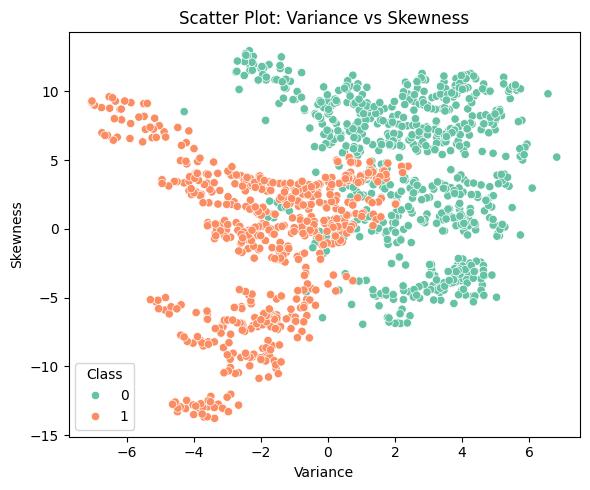

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='Variance', y='Skewness', hue='Class', palette='Set2')
plt.title('Scatter Plot: Variance vs Skewness')
plt.tight_layout()
plt.savefig('task2_scatterplot.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

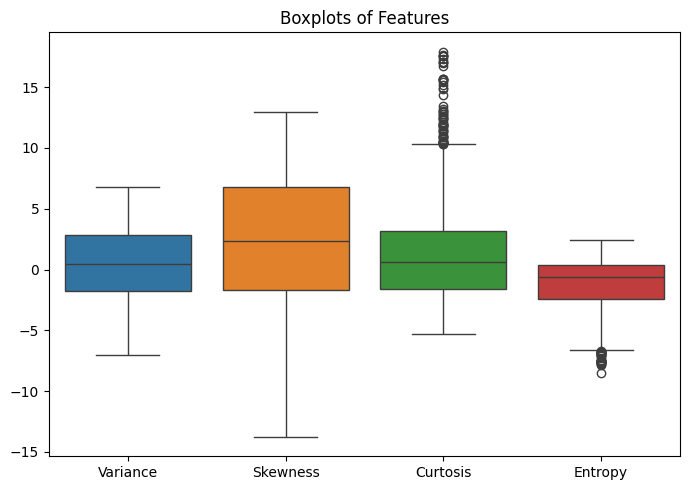

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df.drop('Class', axis=1), )
plt.title('Boxplots of Features')
plt.tight_layout()
plt.savefig('task2_boxplots.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# **6 Task-3**

In [ ]:
#Normalization
from sklearn.preprocessing import MinMaxScaler
X = df.drop('Class', axis=1).values
y = df['Class'].values


scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)



In [ ]:
# Test-Train Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)


print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (1097, 4)
Testing features shape: (275, 4)


# **6 Task-4,5**

In [ ]:
class SingleLayerPerceptron:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors_history = []
        self.weights_history = []
        self.bias_history = []

    def step_activation(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        print("--- Task 5: Model Training  ---")
        for epoch in range(self.epochs):
            errors = 0
            for index, xi in enumerate(X):
                linear_output = np.dot(xi, self.weights) + self.bias
                y_pred = self.step_activation(linear_output)
                update = self.learning_rate * (y[index] - y_pred)
                self.weights += update * xi
                self.bias += update

                if update != 0.0:
                    errors += 1

            self.errors_history.append(errors)
            self.weights_history.append(self.weights.copy())
            self.bias_history.append(self.bias)


            print(f"Epoch {epoch + 1}/{self.epochs} | Misclassified: {errors} |Weights: {self.weights} | Bias: {self.bias:.3f}")

    def predict(self, X):
        # y=wx+b
        linear_output = np.dot(X, self.weights) + self.bias
        return self.step_activation(linear_output)

# Initialize and train the perceptron
perceptron = SingleLayerPerceptron(learning_rate=0.01, epochs=100)
perceptron.fit(X_train, y_train)

# Generate predictions for the test set
y_pred = perceptron.predict(X_test)

--- Task 5: Model Training  ---
Epoch 1/100 | Misclassified: 166 |Weights: [-0.06827408 -0.03866853 -0.05319097  0.01529354] | Bias: 0.080
Epoch 2/100 | Misclassified: 88 |Weights: [-0.0831161  -0.06146315 -0.07687838  0.01162422] | Bias: 0.100
Epoch 3/100 | Misclassified: 57 |Weights: [-0.08731574 -0.0656554  -0.09593051  0.01506002] | Bias: 0.110
Epoch 4/100 | Misclassified: 51 |Weights: [-0.09538568 -0.07974311 -0.09285397  0.01017015] | Bias: 0.120
Epoch 5/100 | Misclassified: 47 |Weights: [-0.09778344 -0.0856403  -0.1002551   0.00578113] | Bias: 0.130
Epoch 6/100 | Misclassified: 45 |Weights: [-0.1058116  -0.08861835 -0.1014938   0.00433029] | Bias: 0.140
Epoch 7/100 | Misclassified: 48 |Weights: [-0.1116004  -0.09912635 -0.10830018  0.00909124] | Bias: 0.140
Epoch 8/100 | Misclassified: 32 |Weights: [-0.11796496 -0.1012441  -0.11616     0.00999082] | Bias: 0.140
Epoch 9/100 | Misclassified: 19 |Weights: [-0.11534745 -0.10082452 -0.11562515  0.01337718] | Bias: 0.150
Epoch 10/100 

# **6 Task-6**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("--- Task 6: Model Evaluation ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

--- Task 6: Model Evaluation ---
Accuracy:  0.9818
Precision: 0.9766
Recall:    0.9843
F1-score:  0.9804


# **Task-7**

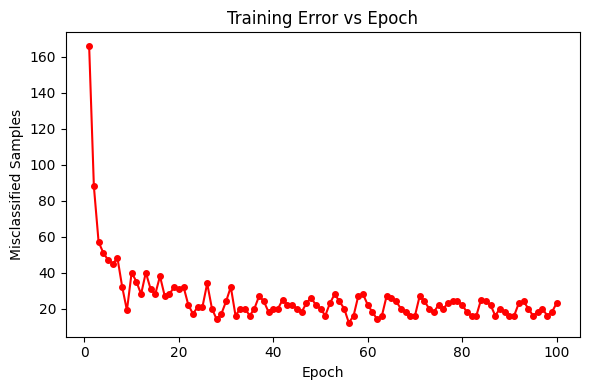

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(perceptron.errors_history) + 1), perceptron.errors_history, marker='o', color='red', markersize=4)
plt.title('Training Error vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Misclassified Samples')
plt.tight_layout()
plt.savefig('task7_training_error.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

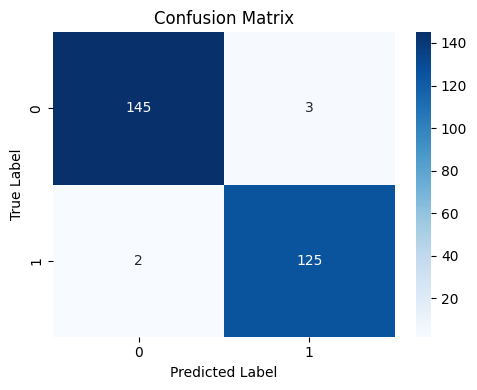

In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('task7_confusion_matrix.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

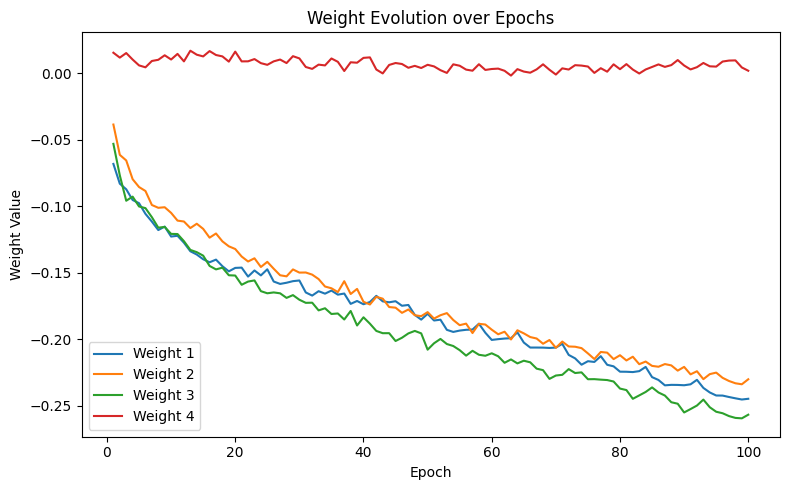

In [ ]:
weights_array = np.array(perceptron.weights_history)

plt.figure(figsize=(8, 5))
for i in range(weights_array.shape[1]):
    plt.plot(range(1, len(weights_array) + 1), weights_array[:, i], label=f'Weight {i+1}')
plt.title('Weight Evolution over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Weight Value')
plt.legend()
plt.tight_layout()
plt.savefig('task7_weight_evolution.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

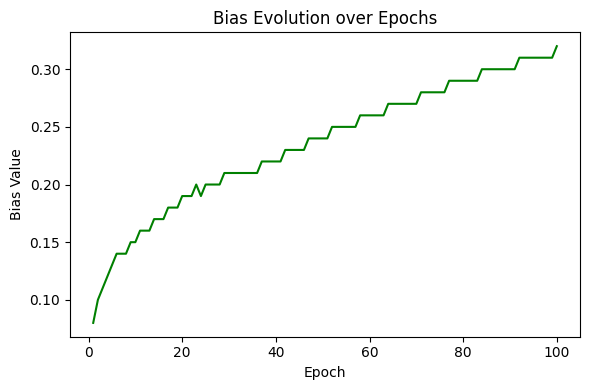

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(perceptron.bias_history) + 1), perceptron.bias_history, color='green')
plt.title('Bias Evolution over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Bias Value')
plt.tight_layout()
plt.savefig('task7_bias_evolution.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
epoch_data = {
    'Epoch': range(1, len(perceptron.errors_history) + 1),
    'Errors': perceptron.errors_history,
    'Bias': perceptron.bias_history
}
for i in range(weights_array.shape[1]):
    epoch_data[f'Weight_{i+1}'] = weights_array[:, i]

epoch_df = pd.DataFrame(epoch_data)
print("--- Section 8: Epoch-wise Learning Table (First 10 Epochs) ---")
print(epoch_df.head(10))

--- Section 8: Epoch-wise Learning Table (First 10 Epochs) ---
   Epoch  Errors  Bias  Weight_1  Weight_2  Weight_3  Weight_4
0      1     166  0.08 -0.068274 -0.038669 -0.053191  0.015294
1      2      88  0.10 -0.083116 -0.061463 -0.076878  0.011624
2      3      57  0.11 -0.087316 -0.065655 -0.095931  0.015060
3      4      51  0.12 -0.095386 -0.079743 -0.092854  0.010170
4      5      47  0.13 -0.097783 -0.085640 -0.100255  0.005781
5      6      45  0.14 -0.105812 -0.088618 -0.101494  0.004330
6      7      48  0.14 -0.111600 -0.099126 -0.108300  0.009091
7      8      32  0.14 -0.117965 -0.101244 -0.116160  0.009991
8      9      19  0.15 -0.115347 -0.100825 -0.115625  0.013377
9     10      40  0.15 -0.122859 -0.105055 -0.120860  0.010205


--- Task 5: Model Training  ---
Epoch 1/50 | Misclassified: 166 |Weights: [-0.00682741 -0.00386685 -0.0053191   0.00152935] | Bias: 0.008
Epoch 2/50 | Misclassified: 88 |Weights: [-0.00831161 -0.00614632 -0.00768784  0.00116242] | Bias: 0.010
Epoch 3/50 | Misclassified: 57 |Weights: [-0.00873157 -0.00656554 -0.00959305  0.001506  ] | Bias: 0.011
Epoch 4/50 | Misclassified: 51 |Weights: [-0.00953857 -0.00797431 -0.0092854   0.00101702] | Bias: 0.012
Epoch 5/50 | Misclassified: 47 |Weights: [-0.00977834 -0.00856403 -0.01002551  0.00057811] | Bias: 0.013
Epoch 6/50 | Misclassified: 45 |Weights: [-0.01058116 -0.00886184 -0.01014938  0.00043303] | Bias: 0.014
Epoch 7/50 | Misclassified: 48 |Weights: [-0.01116004 -0.00991264 -0.01083002  0.00090912] | Bias: 0.014
Epoch 8/50 | Misclassified: 32 |Weights: [-0.0117965  -0.01012441 -0.011616    0.00099908] | Bias: 0.014
Epoch 9/50 | Misclassified: 19 |Weights: [-0.01153474 -0.01008245 -0.01156251  0.00133772] | Bias: 0.015
Epoch 10/50 | Misclass

Epoch 42/50 | Misclassified: 25 |Weights: [-1.67411962 -1.68165419 -1.9377531   0.02675966] | Bias: 2.300
Epoch 43/50 | Misclassified: 22 |Weights: [-1.71561151 -1.69530516 -1.95482494 -0.00252987] | Bias: 2.300
Epoch 44/50 | Misclassified: 22 |Weights: [-1.72259007 -1.75820869 -1.95468825  0.06117477] | Bias: 2.300
Epoch 45/50 | Misclassified: 20 |Weights: [-1.7144354  -1.76308687 -2.0135655   0.07570722] | Bias: 2.300
Epoch 46/50 | Misclassified: 18 |Weights: [-1.74856178 -1.80186373 -1.98904528  0.06826384] | Bias: 2.300
Epoch 47/50 | Misclassified: 23 |Weights: [-1.74259858 -1.77661447 -1.95632799  0.03988022] | Bias: 2.400
Epoch 48/50 | Misclassified: 26 |Weights: [-1.81744293 -1.81979636 -1.93768681  0.05434368] | Bias: 2.400
Epoch 49/50 | Misclassified: 22 |Weights: [-1.85279574 -1.82699711 -1.95605401  0.03821147] | Bias: 2.400
Epoch 50/50 | Misclassified: 20 |Weights: [-1.80916307 -1.79649791 -2.07864375  0.06231482] | Bias: 2.400


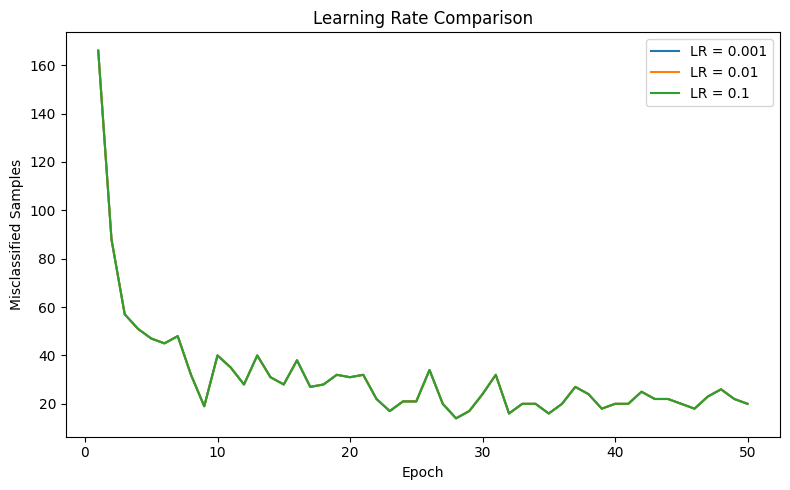

In [ ]:
learning_rates = [0.001, 0.01, 0.1]
plt.figure(figsize=(8, 5))

for lr in learning_rates:
    temp_model = SingleLayerPerceptron(learning_rate=lr, epochs=50)
    temp_model.fit(X_train, y_train)
    plt.plot(range(1, len(temp_model.errors_history) + 1), temp_model.errors_history, label=f'LR = {lr}')

plt.title('Learning Rate Comparison')
plt.xlabel('Epoch')
plt.ylabel('Misclassified Samples')
plt.legend()
plt.tight_layout()
plt.savefig('task9_lr_comparison.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.linear_model import Perceptron

print("--- Section 9: Scikit-Learn Comparison ---")
sk_perceptron = Perceptron(eta0=0.01, random_state=42)
sk_perceptron.fit(X_train, y_train)

sk_y_pred = sk_perceptron.predict(X_test)
sk_accuracy = accuracy_score(y_test, sk_y_pred)

print(f"Custom Perceptron Accuracy: {accuracy:.4f}")
print(f"Sklearn Perceptron Accuracy: {sk_accuracy:.4f}")

--- Section 9: Scikit-Learn Comparison ---
Custom Perceptron Accuracy: 0.9818
Sklearn Perceptron Accuracy: 0.9782
